# Flower manifold: Bayesian FR guidance ablation (v1 bootstrap vs v2 closed-form)

Compares two ways of regularizing the k-NN Fisher-Rao assignment `q^beta(y)` against overfitting the
finite-sample Laguerre partition:

- **`bayesian_fr` (v1, bootstrap)**: `bayesian_fr.fisher_rao_energy_bb` -- Monte Carlo average of `B` draws
  of a `Dirichlet(dirichlet_alpha)` prior over the k retrieved atoms, each combined with the data term into a
  Gibbs posterior.
- **`bayesian_fr_v2` (v2, closed-form)**: `bayesian_fr_v2.fisher_rao_energy_v2` -- places the Dirichlet prior
  directly on the unknown local assignment `pi`, treats `kappa * q^beta(y)` as fractional evidence, and gets a
  Dirichlet posterior in closed form (general Bayesian updating, Bissiri et al. 2016). Both the posterior mean
  `q_bar = (alpha_0 + kappa*q)/a0` and the expected FR energy `E[I(q)] = a0/(a0+1) * I(q_bar)` are closed-form --
  no sampling.

`alpha_0` (v2) controls how strongly `q_bar` is pulled toward uniform (sparsity-preventing prior strength);
`kappa` (v2) controls how much the plug-in evidence `q^beta(y)` is trusted (pseudo-count). v1's analogues are
`dirichlet_alpha` (the bootstrap's Dirichlet concentration) and `B` (number of bootstrap draws -- more draws
approximate the true Gibbs-posterior expectation more accurately, at proportionally higher cost, which is
exactly the cost v2 is designed to avoid by being closed-form).

**Compared**: wall-clock time per condition (`runtime_s`, saved to the results table) and performance
(`mem_ratio`, `fidelity_mse`, same definitions as `02_fr_guidance.ipynb`).

In [1]:
import os, sys, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from guidance import driver, basic_fr, bayesian_fr, bayesian_fr_v2

REGIME = "overtrained"
N = int(os.environ.get("N_DATA", 50))
TAG = f"{REGIME}_N{N}"
ckpt = torch.load(f"checkpoints/score_{TAG}.pt", weights_only=False)
train_config = ckpt["config"]
d, device = train_config["d"], train_config["device"]
X_target = ckpt["X_target"].to(device)
u_target = ckpt["u_target"].to(device)

OUT_DIR = f"checkpoints/N{N}-{REGIME}"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"regime={REGIME}  N={N}  d={d}, device={device}, N_data={X_target.shape[0]}, iters={train_config['iters']}")
print(f"outputs -> {OUT_DIR}/")

regime=overtrained  N=50  d=2, device=cpu, N_data=50, iters=500000
outputs -> checkpoints/N50-overtrained/


In [2]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, train_config["hidden"], train_config["depth"]).to(device)
net.load_state_dict(ckpt["net_state"])
net.eval()
print("Loaded score net.")

Loaded score net.


In [ ]:
ADAPTIVE_CLIP = "adaptive_score_norm"   # sentinel for config["grad_clip"]: cap the guidance grad's
                                         # norm at ||score(z_t, t)|| instead of a fixed constant --
                                         # see score_norm_clip_fn below (same option as 02_fr_guidance.ipynb).

config = {
    "beta_min": train_config["beta_min"], "beta_max": train_config["beta_max"], "T": train_config["T"],
    "n_steps": 1000,
    "n_samples": 200,
    "seed": 10,
    "k_neighbors": 3,
    "ell": 1,
    "mem_ratio_threshold": 1 / 5,

    # held fixed for this ablation (per spec: window=throughout); grad_clip may be a single value or
    # a list of values to sweep (as_list below), same as toy_manifold/04_bayesian_ablation.ipynb
    "lam": 0.1,
    "grad_clip": [1000, ADAPTIVE_CLIP],
    "window": (0.0, 1.0),

    # v2 (bayesian_fr_v2, closed-form): alpha_0 = prior strength (uniformity-imposing),
    # kappa = evidence pseudo-count (how much q^beta(y) is trusted)
    "alpha_0_grid": [0.01, 0.05, 0.1, 5],
    "kappa_grid": [1, 10, 50, 100],

    # v1 (bayesian_fr, bootstrap): dirichlet_alpha = bootstrap prior concentration,
    # B = number of bootstrap draws (more draws -> closer to the true Gibbs-posterior
    # expectation v2 gets in closed form, at proportionally higher cost)
    "bb_alpha_grid": [0.1],
    "bb_B_grid": [16, 64, 256],

    # Decouples the plug-in softmax's TEMPERATURE from the outer 1/sigma_t^2 SCALE shared by
    # basic_fr/bayesian_fr/bayesian_fr_v2 (see basic_fr.fisher_rao_energy's docstring). Without
    # this, the posterior saturates to an exact one-hot late in sampling (verified in float64, not
    # a precision artifact), zeroing the variance term -- and its gradient -- across 45-90%+ of the
    # ambient grid as sigma_t -> 0. 0.05 is comfortably below the typical squared inter-atom
    # spacing on this curve.
    "beta_floor": 0.05,
}

def as_list(v):
    return v if isinstance(v, list) else [v]

def beta(t):
    return config["beta_min"] + t * (config["beta_max"] - config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(config["beta_min"] * t + 0.5 * (config["beta_max"] - config["beta_min"]) * t ** 2))

def sigma2(t):
    return (1 - alpha_bar(t)).clamp(min=1e-4)

def g2(t):
    return beta(t)

## Wire up the generic interface for sampling and guidance

Same `base_step_fn`/`y_fn`/`step_scale_fn` as `02_fr_guidance.ipynb` -- identical reverse SDE step and
denoiser, nothing about this ablation changes the sampler itself, only the guidance energy.

In [4]:
n_steps = config["n_steps"]
dt = config["T"] / n_steps
t_vec_holder = {"t": None}

def make_base_step_fn():
    def base_step_fn(z_t, step_idx):
        k = n_steps - step_idx
        t_vec = torch.full((z_t.shape[0],), (k + 1) * dt, device=device)
        t_vec_holder["t"] = t_vec
        with torch.no_grad():
            eps_hat = net(z_t, t_vec)
            score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
            drift = -0.5 * beta(t_vec)[:, None] * z_t - beta(t_vec)[:, None] * score
            noise = beta(t_vec)[:, None].sqrt() * torch.randn_like(z_t) if k > 0 else 0
        return z_t - drift * dt + noise * dt ** 0.5
    return base_step_fn

def y_fn(z_t):
    t_vec = t_vec_holder["t"]
    eps_hat = net(z_t, t_vec)
    a = alpha_bar(t_vec)
    return (z_t - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt()

def score_norm_clip_fn(z_t):
    # Adaptive grad_clip (see 02_fr_guidance.ipynb): caps the guidance gradient's norm at
    # ||score(z_t, t)|| itself instead of one fixed constant for every x and every t.
    # driver.py's _resolve_clip_norm calls this with the current z_t whenever grad_clip is a
    # callable; t_vec_holder["t"] is already set by whichever step is currently running.
    t_vec = t_vec_holder["t"]
    eps_hat = net(z_t, t_vec)
    score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
    return score.norm(dim=-1, keepdim=True)

def step_scale_fn(step_idx):
    k = n_steps - step_idx
    t_vec = torch.full((config["n_samples"],), (k + 1) * dt, device=device)
    return g2(t_vec)[:, None] * dt

## Guidance energies: bayesian v1 (bootstrap) vs v2 (closed-form), ambient and projected

Both retrieve the same `k_neighbors` nearest atoms via `basic_fr.ann_query` and pin `beta_t = sigma_t^2`, exactly
as in `02_fr_guidance.ipynb`. Both the ambient (`unprojected`) and tangent-restricted (`projected`) energy
factory are built for each method -- `make_guidance_fn` below picks the right one per `jacobian_name`.

In [ ]:
index = basic_fr.build_flat_index(X_target)

def make_v1_energy_fn(dirichlet_alpha, B):
    return bayesian_fr.make_knn_bayesian_fr_energy_fn(
        index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]),
        B=B, dirichlet_alpha=dirichlet_alpha, beta_floor=config["beta_floor"])

def make_v1_projected_energy_fn(dirichlet_alpha, B):
    return bayesian_fr.make_knn_bayesian_projected_energy_fn(
        index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]),
        B=B, dirichlet_alpha=dirichlet_alpha, beta_floor=config["beta_floor"])

def make_v2_energy_fn(alpha_0, kappa):
    return bayesian_fr_v2.make_knn_bayesian_v2_fr_energy_fn(
        index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]),
        alpha_0=alpha_0, kappa=kappa, beta_floor=config["beta_floor"])

def make_v2_projected_energy_fn(alpha_0, kappa):
    return bayesian_fr_v2.make_knn_bayesian_v2_projected_energy_fn(
        index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]),
        alpha_0=alpha_0, kappa=kappa, beta_floor=config["beta_floor"])

## Analytic tangent Jacobian

Closed-form tangent of the flower curve, identical to `02_fr_guidance.ipynb` -- see that notebook for the
derivation. Rank 1 by construction, so this builds `projector_fn(y) -> P` directly.

In [ ]:
def tangent_vec_from_u(u):
    a, b, k = train_config["a"], train_config["b"], train_config["k"]
    r = a + b * torch.cos(k * u)
    dr = -k * b * torch.sin(k * u)
    dx = dr * torch.cos(u) - r * torch.sin(u)
    dy = dr * torch.sin(u) + r * torch.cos(u)
    t = torch.stack([dx, dy], dim=-1)
    return t / t.norm(dim=-1, keepdim=True)

def analytic_tangent_projector(y):
    u = torch.atan2(y[:, 1], y[:, 0])
    t = tangent_vec_from_u(u)
    return torch.einsum("bi,bj->bij", t, t)

JACOBIANS = {"unprojected": None, "projected": analytic_tangent_projector}

# The denoiser's own Jacobian dy/dz_t, exact via jacrev+vmap over y_fn itself (cheap at d=2): used
# to correctly map a y-space guidance gradient into z_t-space instead of assuming dy/dz_t =
# identity (driver.projected_guidance_grad's denoiser_jacobian_fn parameter). Without this,
# projected guidance's correction points in the WRONG direction (median cosine similarity to the
# true grad_z_t I(D_t(z_t), P) was negative) for 50-76% of samples during the noisiest ~20% of a
# reverse trajectory -- verified directly against the toy_manifold checkpoint (same denoiser form).
def _y_fn_single(z_i, t_i):
    eps_hat = net(z_i[None], t_i[None])
    a = alpha_bar(t_i[None])
    return ((z_i[None] - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt())[0]

_denoiser_jacobian_fn_raw = torch.func.vmap(torch.func.jacrev(_y_fn_single))

def denoiser_jacobian_fn(z_t):
    t_vec = t_vec_holder["t"]
    return _denoiser_jacobian_fn_raw(z_t, t_vec).detach()

GRAD_CLIP_FNS = {ADAPTIVE_CLIP: score_norm_clip_fn}   # resolved to a callable at guidance-build time;
                                                       # any other grad_clip value passes through as the
                                                       # fixed scalar it already is (driver.py accepts both).

def resolve_grad_clip(grad_clip):
    return GRAD_CLIP_FNS.get(grad_clip, grad_clip)

def fmt_clip(grad_clip):
    return grad_clip if isinstance(grad_clip, str) else f"{grad_clip:g}"

def make_guidance_fn(method, jacobian_name, grad_clip, **hp):
    projector_fn = JACOBIANS[jacobian_name]
    if method == "bayesian_fr_v1":
        energy_fn = (make_v1_projected_energy_fn(hp["dirichlet_alpha"], hp["B"]) if projector_fn is not None
                     else make_v1_energy_fn(hp["dirichlet_alpha"], hp["B"]))
    elif method == "bayesian_fr_v2":
        energy_fn = (make_v2_projected_energy_fn(hp["alpha_0"], hp["kappa"]) if projector_fn is not None
                     else make_v2_energy_fn(hp["alpha_0"], hp["kappa"]))
    else:
        raise ValueError(method)
    grad_clip = resolve_grad_clip(grad_clip)
    if projector_fn is None:
        return driver.make_autograd_guidance_fn(y_fn, energy_fn, target_range=None, grad_clip=grad_clip)
    return driver.make_projected_guidance_fn(
        y_fn, energy_fn, projector_fn, target_range=None, grad_clip=grad_clip,
        denoiser_jacobian_fn=denoiser_jacobian_fn)

## Metrics

Identical to `02_fr_guidance.ipynb`: `mem_ratio` (fraction of samples whose nearest/2nd-nearest training-atom
distance ratio falls below `mem_ratio_threshold`) and `fidelity_mse` (mean squared distance to the true flower
curve, over non-memorized samples only).

In [7]:
theta_scan = torch.linspace(0, 2 * torch.pi, 4000, device=device)
r_scan = train_config["a"] + train_config["b"] * torch.cos(train_config["k"] * theta_scan)
curve_scan = torch.stack([r_scan * torch.cos(theta_scan), r_scan * torch.sin(theta_scan)], dim=-1)

def dist_to_manifold(X):
    return torch.cdist(X, curve_scan).min(dim=1).values

def is_memorized(X, atoms, thresh):
    d2 = torch.cdist(X, atoms)
    top2 = torch.topk(d2, 2, largest=False, dim=1).values
    ratio = top2[:, 0] / top2[:, 1].clamp(min=1e-8)
    return ratio.lt(thresh)

def evaluate(X):
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    unmem = ~mem
    fidelity = dist_to_manifold(X[unmem]).pow(2).mean().item() if unmem.any() else float("nan")
    return {"mem_ratio": mem.float().mean().item(), "fidelity_mse": fidelity}

In [8]:
def run_condition(guidance_fn):
    torch.manual_seed(config["seed"])
    z_init = torch.randn(config["n_samples"], d, device=device)
    t0 = time.perf_counter()
    if guidance_fn is None:
        x = z_init
        base_step_fn = make_base_step_fn()
        with torch.no_grad():
            for step_idx in range(1, n_steps + 1):
                x = base_step_fn(x, step_idx)
        runtime_s = time.perf_counter() - t0
        return x.detach(), runtime_s
    progress_lo, progress_hi = config["window"]
    z_final, _ = driver.guided_reverse_loop(
        z_init, n_steps, make_base_step_fn(), guidance_fn,
        progress_lo=progress_lo, progress_hi=progress_hi, ell=config["ell"], lam=config["lam"],
        step_scale_fn=step_scale_fn)
    runtime_s = time.perf_counter() - t0
    return z_final.detach(), runtime_s

X_unguided, t_unguided = run_condition(None)
baseline = {"method": "unguided", "jacobian": "n/a", "runtime_s": t_unguided, **evaluate(X_unguided)}
print(baseline)

{'method': 'unguided', 'jacobian': 'n/a', 'runtime_s': 0.4049164579482749, 'mem_ratio': 0.3499999940395355, 'fidelity_mse': 0.00024029520864132792}


## Full sweep: jacobian x v1 (`dirichlet_alpha` x `B`) and jacobian x v2 (`alpha_0` x `kappa`)

`window=throughout`, `grad_clip`/`lam` fixed as above -- now crossed with `jacobian in {unprojected, projected}`
so each method's own regularization hyperparameters are compared both in the full ambient space and restricted
to the tangent.

In [9]:
rows = [baseline]
samples_cache = {("unguided", "n/a"): X_unguided}

for jacobian_name in JACOBIANS:
    for dirichlet_alpha in config["bb_alpha_grid"]:
        for B in config["bb_B_grid"]:
            for grad_clip in as_list(config["grad_clip"]):
                guidance_fn = make_guidance_fn("bayesian_fr_v1", jacobian_name, grad_clip,
                                                dirichlet_alpha=dirichlet_alpha, B=B)
                X, runtime_s = run_condition(guidance_fn)
                row = {"method": "bayesian_fr_v1", "jacobian": jacobian_name, "dirichlet_alpha": dirichlet_alpha, "B": B,
                       "grad_clip": grad_clip, "runtime_s": runtime_s, **evaluate(X)}
                rows.append(row)
                samples_cache[("bayesian_fr_v1", jacobian_name, dirichlet_alpha, B, grad_clip)] = X
                print(row)

for jacobian_name in JACOBIANS:
    for alpha_0 in config["alpha_0_grid"]:
        for kappa in config["kappa_grid"]:
            for grad_clip in as_list(config["grad_clip"]):
                guidance_fn = make_guidance_fn("bayesian_fr_v2", jacobian_name, grad_clip,
                                                alpha_0=alpha_0, kappa=kappa)
                X, runtime_s = run_condition(guidance_fn)
                row = {"method": "bayesian_fr_v2", "jacobian": jacobian_name, "alpha_0": alpha_0, "kappa": kappa,
                       "grad_clip": grad_clip, "runtime_s": runtime_s, **evaluate(X)}
                rows.append(row)
                samples_cache[("bayesian_fr_v2", jacobian_name, alpha_0, kappa, grad_clip)] = X
                print(row)

df = pd.DataFrame(rows)
df.to_csv(f"{OUT_DIR}/bayesian_ablation_results.csv", index=False)
print(f"\n{len(df)} configs run.")
df

{'method': 'bayesian_fr_v1', 'jacobian': 'unprojected', 'dirichlet_alpha': 0.1, 'B': 16, 'grad_clip': 1000, 'runtime_s': 2.2761829170631245, 'mem_ratio': 0.125, 'fidelity_mse': 0.0007110253209248185}
{'method': 'bayesian_fr_v1', 'jacobian': 'unprojected', 'dirichlet_alpha': 0.1, 'B': 16, 'grad_clip': 'adaptive_score_norm', 'runtime_s': 2.875432249973528, 'mem_ratio': 0.46000000834465027, 'fidelity_mse': 0.0001764300250215456}
{'method': 'bayesian_fr_v1', 'jacobian': 'unprojected', 'dirichlet_alpha': 0.1, 'B': 64, 'grad_clip': 1000, 'runtime_s': 2.210347249987535, 'mem_ratio': 0.07999999821186066, 'fidelity_mse': 0.0006341851549223065}
{'method': 'bayesian_fr_v1', 'jacobian': 'unprojected', 'dirichlet_alpha': 0.1, 'B': 64, 'grad_clip': 'adaptive_score_norm', 'runtime_s': 2.5698038750560954, 'mem_ratio': 0.4000000059604645, 'fidelity_mse': 0.00011592706141527742}
{'method': 'bayesian_fr_v1', 'jacobian': 'unprojected', 'dirichlet_alpha': 0.1, 'B': 256, 'grad_clip': 1000, 'runtime_s': 3.38

,method,jacobian,runtime_s,mem_ratio,fidelity_mse,dirichlet_alpha,B,grad_clip,alpha_0,kappa
0,unguided,n/a,0.404916,0.350,0.000240,NaN,NaN,NaN,NaN,NaN
1,bayesian_fr_v1,unprojected,2.276183,0.125,0.000711,0.1,16.0,1000,NaN,NaN
2,bayesian_fr_v1,unprojected,2.875432,0.460,0.000176,0.1,16.0,adaptive_score_norm,NaN,NaN
3,bayesian_fr_v1,unprojected,2.210347,0.080,0.000634,0.1,64.0,1000,NaN,NaN
4,bayesian_fr_v1,unprojected,2.569804,0.400,0.000116,0.1,64.0,adaptive_score_norm,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
72,bayesian_fr_v2,projected,1.822056,0.380,0.000258,NaN,NaN,adaptive_score_norm,5.0,10.0
73,bayesian_fr_v2,projected,1.416711,0.215,0.000234,NaN,NaN,1000,5.0,50.0
74,bayesian_fr_v2,projected,1.708738,0.360,0.000242,NaN,NaN,adaptive_score_norm,5.0,50.0
75,bayesian_fr_v2,projected,1.364944,0.165,0.000278,NaN,NaN,1000,5.0,100.0


## Combined error and speed summary

Same normalization as `02_fr_guidance.ipynb`: `combined_error = fidelity_mse/baseline_fidelity_mse * 0.01 +
mem_ratio/baseline_mem_ratio` (2.0 = no change from unguided; lower is better on both axes). Now broken out by
`(method, jacobian)`.

In [10]:
df["fidelity_rel"] = df["fidelity_mse"] / baseline["fidelity_mse"]
df["mem_rel"] = df["mem_ratio"] / baseline["mem_ratio"]
df["combined_error"] = df["fidelity_rel"] + df["mem_rel"]
df.to_csv(f"{OUT_DIR}/bayesian_ablation_results.csv", index=False)

guided = df[df["method"] != "unguided"]
print(f"baseline: runtime_s={baseline['runtime_s']:.2f}  combined_error=2.000 (mem_ratio={baseline['mem_ratio']:.3f}, fidelity_mse={baseline['fidelity_mse']:.4g})\n")

print("Speed summary (wall-clock seconds per 200-sample, 1000-step condition):")
print(guided.groupby(["method", "jacobian"])["runtime_s"].agg(["mean", "std", "min", "max"]).to_string())

print("\nPerformance summary (combined_error, lower is better):")
print(guided.groupby(["method", "jacobian"])["combined_error"].agg(["median", "min", "max"]).to_string())

print("\nBest config per (method, jacobian):")
best = guided.loc[guided.groupby(["method", "jacobian"])["combined_error"].idxmin()]
print(best[["method", "jacobian", "dirichlet_alpha", "B", "alpha_0", "kappa", "grad_clip",
            "runtime_s", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

baseline: runtime_s=0.40  combined_error=2.000 (mem_ratio=0.350, fidelity_mse=0.0002403)

Speed summary (wall-clock seconds per 200-sample, 1000-step condition):
                                mean       std       min       max
method         jacobian                                           
bayesian_fr_v1 projected    2.560399  0.666273  1.804527  3.421359
               unprojected  3.047663  1.034105  2.210347  4.964918
bayesian_fr_v2 projected    1.647772  0.251830  1.298418  2.386652
               unprojected  1.946708  0.268183  1.564458  2.722791

Performance summary (combined_error, lower is better):
                              median       min       max
method         jacobian                                 
bayesian_fr_v1 projected    2.110103  1.545260  2.938056
               unprojected  2.458136  1.625293  3.324199
bayesian_fr_v2 projected    1.956044  1.339363  5.292292
               unprojected  1.973499  1.281570  4.621124

Best config per (method, jacobian):
 

## Robustness gap: does v2 close the distance to v1 more when unprojected?

The working hypothesis: v2's closed-form smoothing should help relatively MORE in the ambient (unprojected)
energy, where the raw plug-in `q^beta(y)` is noisier (no tangent restriction narrowing which neighbor
differences matter). `gap = median(combined_error, v1) - median(combined_error, v2)` per jacobian -- a smaller
(or negative, meaning v2 wins outright) gap unprojected than projected would support the hypothesis.

In [11]:
median_by = guided.groupby(["method", "jacobian"])["combined_error"].median().unstack("method")
median_by["v1_minus_v2"] = median_by["bayesian_fr_v1"] - median_by["bayesian_fr_v2"]
print("Median combined_error by method x jacobian, and the v1-v2 gap (negative = v2 better):\n")
print(median_by.to_string())

Median combined_error by method x jacobian, and the v1-v2 gap (negative = v2 better):

method       bayesian_fr_v1  bayesian_fr_v2  v1_minus_v2
jacobian                                                
projected          2.110103        1.956044     0.154059
unprojected        2.458136        1.973499     0.484637


## Speed vs. performance scatter

Each point is one hyperparameter config; color = method, marker = jacobian. v2 should sit systematically left
of v1 (cheaper) at comparable `combined_error` regardless of jacobian, since it replaces v1's `B`-sample Monte
Carlo average with a single closed-form expression; the interesting question is whether the unprojected (`^`)
v2 points close the gap to v1 more than the projected (`o`) ones do.

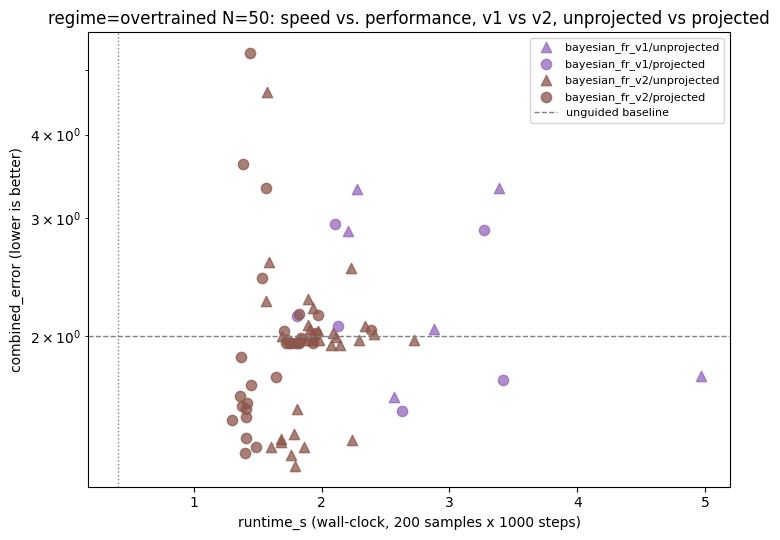

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = {"bayesian_fr_v1": "tab:purple", "bayesian_fr_v2": "tab:brown"}
markers = {"unprojected": "^", "projected": "o"}
for method, color in colors.items():
    for jacobian_name, marker in markers.items():
        sub = guided[(guided.method == method) & (guided.jacobian == jacobian_name)]
        ax.scatter(sub["runtime_s"], sub["combined_error"], color=color, marker=marker, alpha=0.75, s=55,
                   label=f"{method}/{jacobian_name}")
ax.axhline(2.0, color="gray", ls="--", lw=1, label="unguided baseline")
ax.axvline(baseline["runtime_s"], color="gray", ls=":", lw=1)
ax.set_xlabel("runtime_s (wall-clock, 200 samples x 1000 steps)")
ax.set_ylabel("combined_error (lower is better)")
ax.set_yscale("log")
ax.set_title(f"regime={REGIME} N={N}: speed vs. performance, v1 vs v2, unprojected vs projected")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/bayesian_speed_vs_performance.png", dpi=120)
plt.show()

## Scatter view: unguided vs. best config per (method, jacobian)

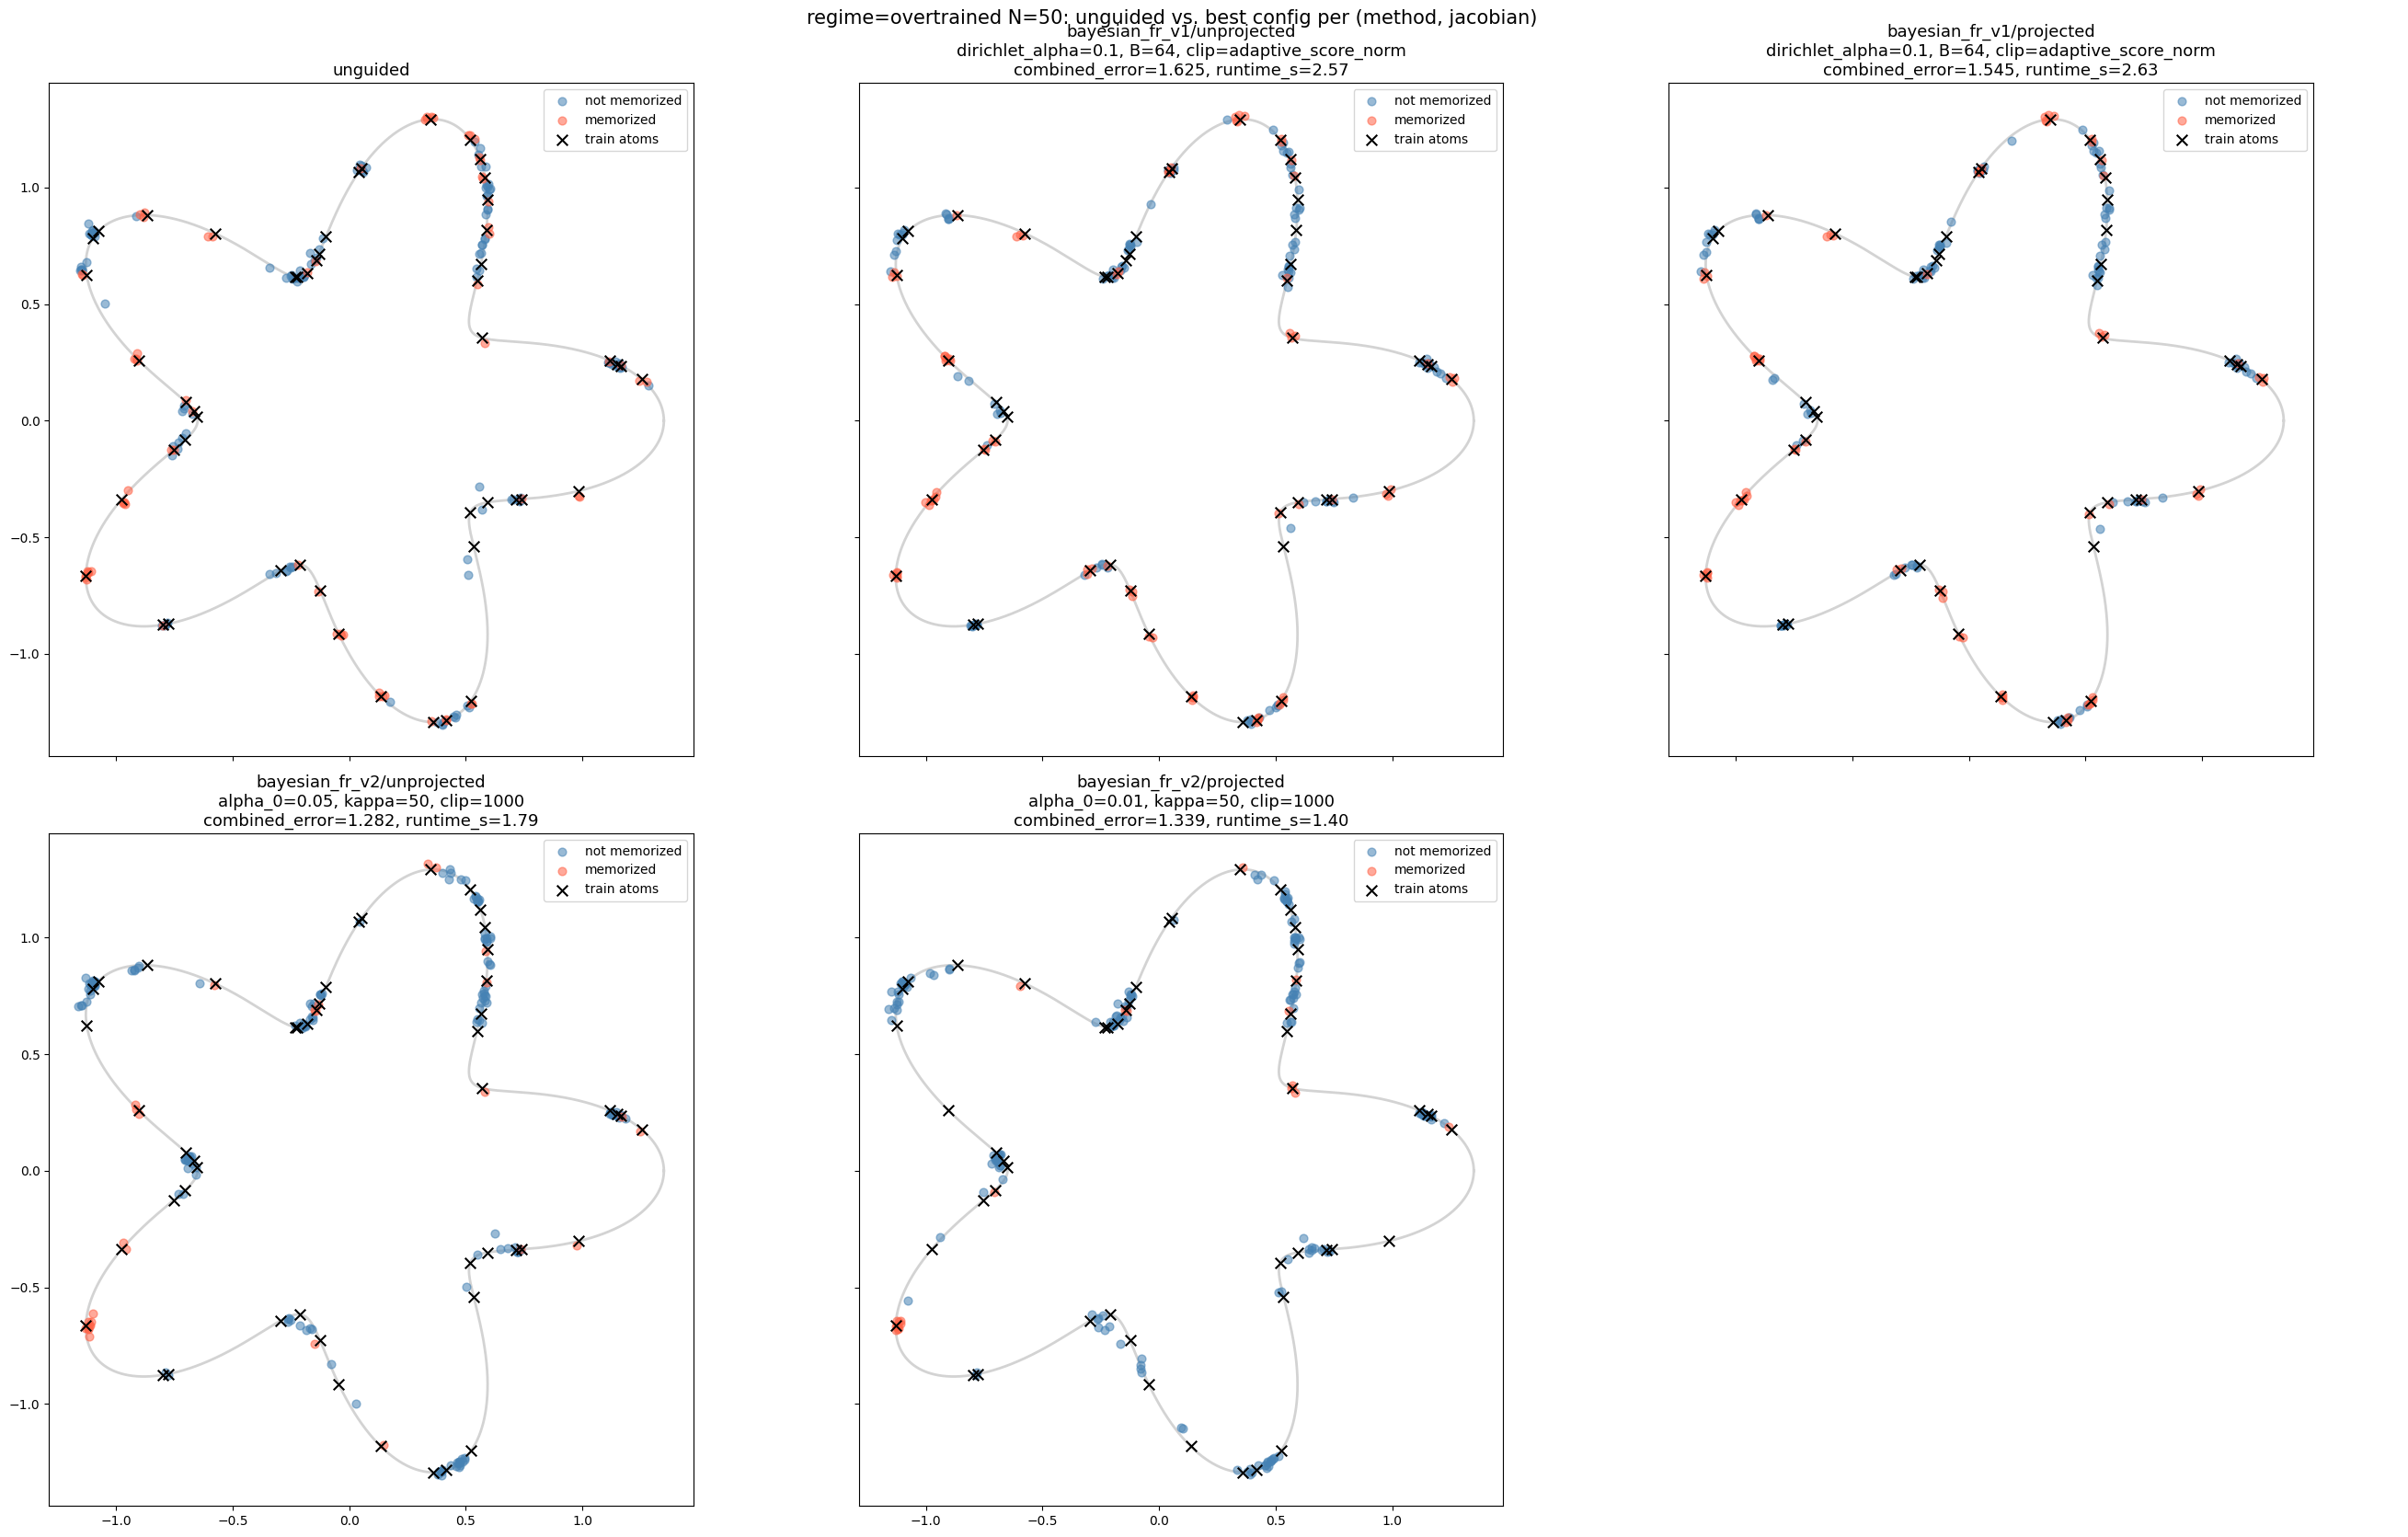

In [13]:
GROUPS = [("bayesian_fr_v1", "unprojected"), ("bayesian_fr_v1", "projected"),
          ("bayesian_fr_v2", "unprojected"), ("bayesian_fr_v2", "projected")]

best_per_group = {}
for method, jacobian_name in GROUPS:
    sub = guided[(guided.method == method) & (guided.jacobian == jacobian_name)]
    if len(sub):
        best_per_group[(method, jacobian_name)] = sub.sort_values("combined_error").iloc[0]

picks = [("unguided", "n/a")] + list(best_per_group.keys())
N_COLS = 3
n_rows = (len(picks) + N_COLS - 1) // N_COLS
PANEL_W, PANEL_H = 9, 8.5
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(PANEL_W * N_COLS, PANEL_H * n_rows), sharex=True, sharey=True)
axes = axes.flatten()
for ax, key in zip(axes, picks):
    if key == ("unguided", "n/a"):
        X, label = X_unguided, "unguided"
    else:
        method, jacobian_name = key
        row = best_per_group[key]
        hp_str = (f"dirichlet_alpha={row['dirichlet_alpha']:g}, B={int(row['B'])}" if method == "bayesian_fr_v1"
                  else f"alpha_0={row['alpha_0']:g}, kappa={row['kappa']:g}")
        hp_key = ((row["dirichlet_alpha"], row["B"]) if method == "bayesian_fr_v1"
                  else (row["alpha_0"], row["kappa"]))
        X = samples_cache[(method, jacobian_name, *hp_key, row["grad_clip"])]
        label = (f"{method}/{jacobian_name}\n{hp_str}, clip={fmt_clip(row['grad_clip'])}"
                  f"\ncombined_error={row['combined_error']:.3f}, runtime_s={row['runtime_s']:.2f}")
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    ax.plot(curve_scan[:, 0].cpu(), curve_scan[:, 1].cpu(), color="lightgray", lw=2, zorder=0)
    ax.scatter(X[~mem, 0].cpu(), X[~mem, 1].cpu(), s=40, color="steelblue", alpha=0.55, label="not memorized", zorder=1)
    ax.scatter(X[mem, 0].cpu(), X[mem, 1].cpu(), s=40, color="tomato", alpha=0.55, label="memorized", zorder=2)
    ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=70, color="black", marker="x", label="train atoms", zorder=3)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=10)
    ax.set_aspect("equal")
for ax in axes[len(picks):]:
    ax.axis("off")
fig.suptitle(f"regime={REGIME} N={N}: unguided vs. best config per (method, jacobian)", fontsize=15)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/bayesian_best_configs_scatter.png", dpi=120)
plt.show()